In [5]:
# ======================================
# 📊 Pandas Data Transformation + Analysis
# Dataset: Indian_Kids_Screen_Time.csv
# ======================================


In [7]:
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
# 1️⃣ Load Dataset
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [24]:
# 2️⃣ Basic Overview
print("Shape:", df.shape)

Shape: (9712, 8)


In [22]:
print("\nColumns:", df.columns.tolist())


Columns: ['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio', 'Health_Impacts', 'Urban_or_Rural']


In [20]:
print("\nData Types:\n", df.dtypes)


Data Types:
 Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
dtype: object


In [18]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64


In [14]:
print("\nFirst 5 Rows:\n", df.head())


First 5 Rows:
    Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4    

In [26]:
# 3️⃣ Clean Column Names
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]

In [28]:
# 4️⃣ Convert Numeric Columns (if stored as text)
for col in df.columns:
    if df[col].dtype == 'object':
        cleaned = df[col].astype(str).str.replace(',', '').str.replace('%', '').str.strip()
        num = pd.to_numeric(cleaned, errors='coerce')
        if num.notnull().mean() > 0.6:
            df[col] = num

In [30]:
# 5️⃣ Create Screen-Time Features
if 'avg_daily_screen_time_hr' in df.columns:
    df['total_screen_minutes'] = df['avg_daily_screen_time_hr'] * 60
    df['avg_screen_minutes'] = df['avg_daily_screen_time_hr'] * 60

In [32]:
# 6️⃣ Drop Duplicates
df.drop_duplicates(inplace=True)

In [34]:
# 7️⃣ Filtering Example
high_usage = df[df['avg_daily_screen_time_hr'] > 5]
print("\nKids with more than 5 hours screen time:\n", high_usage.head())


Kids with more than 5 hours screen time:
     age  gender  avg_daily_screen_time_hr primary_device  \
4    12  Female                      5.89     Smartphone   
13   11    Male                      6.08             TV   
14   15    Male                      6.15     Smartphone   
16   10  Female                      7.10     Smartphone   
17   13  Female                      6.98     Smartphone   

    exceeded_recommended_limit  educational_to_recreational_ratio  \
4                         True                               0.49   
13                        True                               0.48   
14                        True                               0.40   
16                        True                               0.43   
17                        True                               0.48   

            health_impacts urban_or_rural  total_screen_minutes  \
4      Poor Sleep, Anxiety          Urban                 353.4   
13              Eye Strain          Rural      

In [36]:
# 8️⃣ Sorting Example
sorted_df = df.sort_values(by='avg_daily_screen_time_hr', ascending=False)
print("\nTop 5 by Screen Time:\n", sorted_df[['age', 'gender', 'avg_daily_screen_time_hr']].head())


Top 5 by Screen Time:
       age  gender  avg_daily_screen_time_hr
4298   10  Female                     13.89
934    10  Female                     13.01
1769    9    Male                     12.80
1870   10    Male                     12.40
1321   10  Female                     12.09


In [38]:
# 9️⃣ GroupBy Example
if 'gender' in df.columns:
    print("\nAverage Screen Time by Gender:\n", df.groupby('gender')['avg_daily_screen_time_hr'].mean())


Average Screen Time by Gender:
 gender
Female    4.348614
Male      4.386216
Name: avg_daily_screen_time_hr, dtype: float64


In [42]:
# 1️⃣0️⃣ Descriptive Statistics
print("\nDescriptive Statistics:\n")
df.describe()


Descriptive Statistics:



,age,avg_daily_screen_time_hr,educational_to_recreational_ratio,total_screen_minutes,avg_screen_minutes
count,9668.000000,9668.000000,9668.000000,9668.000000,9668.000000
mean,12.992760,4.367780,0.427028,262.066818,262.066818
std,3.158931,1.703002,0.073185,102.180123,102.180123
min,8.000000,0.000000,0.300000,0.000000,0.000000
25%,10.000000,3.427500,0.370000,205.650000,205.650000
50%,13.000000,4.440000,0.430000,266.400000,266.400000
75%,16.000000,5.380000,0.480000,322.800000,322.800000
max,18.000000,13.890000,0.600000,833.400000,833.400000


In [67]:
# 1️⃣1️⃣ Mean / Median / Mode / Std
for col in df.select_dtypes(include='number').columns:
    print(f"\nColumn: {col}")
    print('mean:', df[col].mean())

    print('Median:', df[col].median())
    print('Mode:' ,df[col].mode().iloc[0])
    print('std:' , df[col].std())


Column: age
mean: 12.992759619362847
Median: 13.0
Mode: 17
std: 3.158930966461585

Column: avg_daily_screen_time_hr
mean: 4.367780306164667
Median: 4.44
Mode: 0.0
std: 1.7030020580312428

Column: educational_to_recreational_ratio
mean: 0.42702834091849395
Median: 0.43
Mode: 0.45
std: 0.07318489025220766

Column: total_screen_minutes
mean: 262.06681836988
Median: 266.40000000000003
Mode: 0.0
std: 102.18012348187501

Column: avg_screen_minutes
mean: 262.06681836988
Median: 266.40000000000003
Mode: 0.0
std: 102.18012348187501


In [74]:
# 1️⃣2️⃣ Correlation Matrix
print("\nCorrelation Matrix:\n", df.select_dtypes(include='number').corr())

# print("\nCorrelation Matrix:\n", df.corr())


Correlation Matrix:
                                         age  avg_daily_screen_time_hr  \
age                                1.000000                  0.108873   
avg_daily_screen_time_hr           0.108873                  1.000000   
educational_to_recreational_ratio -0.488017                 -0.081445   
total_screen_minutes               0.108873                  1.000000   
avg_screen_minutes                 0.108873                  1.000000   

                                   educational_to_recreational_ratio  \
age                                                        -0.488017   
avg_daily_screen_time_hr                                   -0.081445   
educational_to_recreational_ratio                           1.000000   
total_screen_minutes                                       -0.081445   
avg_screen_minutes                                         -0.081445   

                                   total_screen_minutes  avg_screen_minutes  
age                         

In [76]:
 # 1️⃣3️⃣ Value Counts for Categories
for col in ['gender', 'primary_device', 'urban_or_rural']:
    if col in df.columns:
        print(f"\nValue Counts for {col}:\n", df[col].value_counts())


Value Counts for gender:
 gender
Male      4928
Female    4740
Name: count, dtype: int64

Value Counts for primary_device:
 primary_device
Smartphone    4540
TV            2478
Laptop        1431
Tablet        1219
Name: count, dtype: int64

Value Counts for urban_or_rural:
 urban_or_rural
Urban    6810
Rural    2858
Name: count, dtype: int64


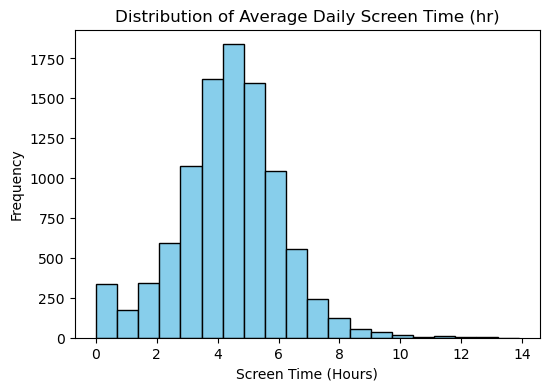

In [78]:
# 1️⃣4️⃣ Visualization
plt.figure(figsize=(6,4))
df['avg_daily_screen_time_hr'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Average Daily Screen Time (hr)")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Frequency")
plt.show()

In [80]:
# 1️⃣5️⃣ Quick Insights
print("\n=== Quick Insights ===")
print(f"Total records: {len(df)}")
if 'avg_daily_screen_time_hr' in df.columns:
    median = df['avg_daily_screen_time_hr'].median()
    q1 = df['avg_daily_screen_time_hr'].quantile(0.25)
    q3 = df['avg_daily_screen_time_hr'].quantile(0.75)
    print(f"Median Screen Time: {median:.2f} hrs/day")
    print(f"IQR (25%-75%): {q1:.2f} – {q3:.2f} hrs/day")
if 'primary_device' in df.columns:
    print("Most Used Device:", df['primary_device'].value_counts().idxmax())
if 'exceeded_recommended_limit' in df.columns:
    pct = df['exceeded_recommended_limit'].mean() * 100
    print(f"Exceeded Recommended Limit: {pct:.1f}% users")


=== Quick Insights ===
Total records: 9668
Median Screen Time: 4.44 hrs/day
IQR (25%-75%): 3.43 – 5.38 hrs/day
Most Used Device: Smartphone
Exceeded Recommended Limit: 85.8% users
